## Study Design & Problem Formulation

This project develops a short-term forecasting workflow for emergency department demand to support staffing, patient flow, and resource allocation decisions.

The delivered modeling scope focuses on four operational horizons: 1 hour, 6 hours, 24 hours, and 72 hours ahead. These horizons are short enough to support immediate staffing decisions, shift planning, next-day preparation, and near-term surge readiness.

The primary target is patient arrival volume. Operational resource pressure is evaluated with available signals such as admissions, wait times, underprediction rates, and peak-period errors, giving the analysis a view of both expected demand and staffing risk.


## Imports and Setup

In [1]:
from pathlib import Path
import json
import importlib.util
import os
import subprocess
import sys
import warnings

import pandas as pd
from urllib.parse import urlencode
from urllib.request import urlopen


* Install Modeling Libraries*

In [2]:
# Install the plotting, statistical, and modeling libraries required by the remaining workflow.
required_modeling_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "statsmodels": "statsmodels",
    "lightgbm": "lightgbm",
}

missing_packages = [
    package_name
    for module_name, package_name in required_modeling_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All modeling libraries are already installed.")


All modeling libraries are already installed.


* Extended Modeling Imports*

In [3]:
# Import analysis, statistical testing, and modeling tools used below.
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from pandas.tseries.holiday import USFederalHolidayCalendar

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb

warnings.filterwarnings("ignore", category=InterpolationWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")


## Data Source and Reproducibility

This analysis uses the [Hospital Emergency Room dataset](https://www.kaggle.com/datasets/xavierberge/hospital-emergency-dataset) from Kaggle as the raw data source. The workflow preserves reproducibility by retrieving the dataset through the Kaggle API and retaining the extracted files in the project's raw-data directory.

> **Reproducibility note:** A configured Kaggle CLI and valid API token are required to reproduce the download step. Using the source dataset directly ensures that the data preparation and forecasting workflow can be recreated from the raw files.

In [4]:
# Save raw data in the notebook data folder when running from the project root.
data_dir = Path("Notebook/data/raw") if Path("Notebook").exists() else Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)
raw_csv_path = data_dir / "Hospital ER_Data.csv"

# Reuse the local raw file when present; otherwise download it with the Kaggle CLI.
if raw_csv_path.exists():
    print(f"Raw dataset already exists at {raw_csv_path}")
else:
    try:
        subprocess.run(
            [
                "kaggle",
                "datasets",
                "download",
                "-d",
                "xavierberge/hospital-emergency-dataset",
                "-p",
                str(data_dir),
                "--unzip",
            ],
            check=True,
        )
        print(f"Downloaded dataset to {data_dir}")
    except FileNotFoundError:
        print("Kaggle CLI not found. Install it with `pip install kaggle` and configure your Kaggle API token.")
        sys.exit(1)
    except subprocess.CalledProcessError as exc:
        print(f"Kaggle download failed with exit code {exc.returncode}.")
        sys.exit(exc.returncode)


Raw dataset already exists at data\raw\Hospital ER_Data.csv


### Raw Data Inspection

In [5]:
# Locate the raw ER file whether the notebook is run from the project root or Notebook/.
raw_path_candidates = [
    Path("Notebook/data/raw/Hospital ER_Data.csv"),
    Path("data/raw/Hospital ER_Data.csv"),
]
raw_path = next((path for path in raw_path_candidates if path.exists()), None)

if raw_path is None:
    searched_paths = "\n".join(str(path) for path in raw_path_candidates)
    raise FileNotFoundError(f"Expected raw CSV was not found. Searched:\n{searched_paths}")

# Read-only preview of the downloaded patient-level ER records.
raw_er = pd.read_csv(raw_path)

print(f"Raw data path: {raw_path}")
print(f"Raw data shape: {raw_er.shape}")
print("\nRaw data columns:")
print(raw_er.columns.tolist())
print("\nMissing values by column:")
print(raw_er.isna().sum())


Raw data path: data\raw\Hospital ER_Data.csv
Raw data shape: (9216, 12)

Raw data columns:
['Patient Id', 'Patient Admission Date', 'Patient First Inital', 'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM']

Missing values by column:
Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64


* Raw Data Preview*

In [6]:
print("\nRaw data preview:")
raw_er.head()



Raw data preview:


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


### Short-Term Forecasting: 1 to 72 Hours

The short-term forecasting task estimates emergency department demand over the next hour through the next 72 hours to support immediate staffing, room availability, and patient-flow readiness.

The primary objective is hourly ER arrival-volume forecasting. Operational pressure is assessed alongside volume through admission and wait-time patterns, which indicate whether a future hour may require additional beds, staffing attention, or patient-flow support.

An hourly dataset is used because ER demand can shift quickly within the same day. This structure supports modeling of recent arrival patterns, daily cycles, weekend effects, and short-window changes in operational pressure.

## Data Ingestion & Integration

The raw hospital ER file contains one record per patient encounter. The key timestamp for time-series processing is `Patient Admission Date`, which defines the arrival time for each encounter. Patient-level encounters are aggregated into hourly windows and saved as `hourly_patient_volume.csv`.

The resulting base hourly dataset contains the time index, target, and operational outcome summaries only: `DateTime_Hour`, `Patient_Count`, `Avg_Waittime`, and `Admission_Count`. Calendar, external weather, and lag predictors are intentionally created later in the Feature Engineering section so the raw demand table stays clean and reproducible.

> **Why this matters:** This separation makes the workflow easier to explain: first build a trustworthy hourly target series, then engineer modeling signals from it.


* Short-Term Forecast Dataset*

In [7]:
# Reuse the raw path from the inspection step when available; otherwise locate it directly.
if "raw_path" not in globals() or raw_path is None or not Path(raw_path).exists():
    raw_path_candidates = [
        Path("Notebook/data/raw/Hospital ER_Data.csv"),
        Path("data/raw/Hospital ER_Data.csv"),
    ]
    raw_path = next((path for path in raw_path_candidates if path.exists()), None)

    if raw_path is None:
        searched_paths = "\n".join(str(path) for path in raw_path_candidates)
        raise FileNotFoundError(f"Expected raw CSV was not found. Searched:\n{searched_paths}")

raw_path = Path(raw_path)
data_dir = raw_path.parent.parent
hourly_path = data_dir / "hourly_patient_volume.csv"

# Load the raw visit-level ER records when this section is run independently.
raw_er = pd.read_csv(raw_path)

# Parse the admission timestamp used to order visits over time.
raw_er["Patient_Admission_Timestamp"] = pd.to_datetime(
    raw_er["Patient Admission Date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce",
)

# Stop early if any timestamp cannot be parsed, because forecasting requires chronological integrity.
missing_timestamps = raw_er["Patient_Admission_Timestamp"].isna().sum()
if missing_timestamps:
    raise ValueError(f"Unable to parse {missing_timestamps} admission timestamps.")

# Convert each visit timestamp into an hourly bucket for short-term forecasting.
raw_er["DateTime_Hour"] = raw_er["Patient_Admission_Timestamp"].dt.floor("h")

# Aggregate patient visits into one base row per observed arrival hour.
hourly_forecast = (
    raw_er.groupby("DateTime_Hour")
    .agg(
        Patient_Count=("Patient Id", "count"),
        Avg_Waittime=("Patient Waittime", "mean"),
        Admission_Count=("Patient Admission Flag", "sum"),
    )
    .reset_index()
)

hourly_forecast = hourly_forecast[
    [
        "DateTime_Hour",
        "Patient_Count",
        "Avg_Waittime",
        "Admission_Count",
    ]
]
hourly_forecast["Avg_Waittime"] = hourly_forecast["Avg_Waittime"].round(2)
hourly_forecast["DateTime_Hour"] = hourly_forecast["DateTime_Hour"].dt.strftime("%Y-%m-%d %H:%M")

# Save the reproducible base short-term forecasting dataset generated from raw data.
hourly_forecast.to_csv(hourly_path, index=False)
print(f"Saved base hourly forecasting dataset to {hourly_path}")


Saved base hourly forecasting dataset to data\hourly_patient_volume.csv


### Dataset Validation Check

In [8]:
# Inspect the generated hourly forecasting dataset.
print(f"\nHourly forecasting data shape: {hourly_forecast.shape}")
print("Hourly forecasting columns:")
print(hourly_forecast.columns.tolist())

duplicate_hours = hourly_forecast["DateTime_Hour"].duplicated().sum()
print(f"\nDuplicate hourly timestamps: {duplicate_hours}")

hourly_timestamps = pd.to_datetime(hourly_forecast["DateTime_Hour"])
is_chronological = hourly_timestamps.is_monotonic_increasing
print(f"Chronologically sorted: {is_chronological}")



Hourly forecasting data shape: (6757, 4)
Hourly forecasting columns:
['DateTime_Hour', 'Patient_Count', 'Avg_Waittime', 'Admission_Count']

Duplicate hourly timestamps: 0
Chronologically sorted: True


* Hourly Forecast Preview*

In [9]:
print("\nHourly Forecasting Data:")
hourly_forecast.head()



Hourly Forecasting Data:


,DateTime_Hour,Patient_Count,Avg_Waittime,Admission_Count
0,2023-04-01 01:00,2,37.5,2
1,2023-04-01 02:00,1,12.0,0
2,2023-04-01 04:00,1,21.0,0
3,2023-04-01 06:00,1,52.0,1
4,2023-04-01 07:00,1,50.0,1


## Data Cleaning & Quality Assurance

This section verifies that the source fields required for hourly aggregation are complete, valid, and chronologically reliable. The primary modeling dataset for the current workflow is the generated hourly forecasting table, so quality checks focus on timestamp integrity, duplicate records, missing modeling values, chronological order, and reasonable numeric ranges.

* Raw Data Quality Checks*

In [10]:
# Minimal source QA for fields used to build the hourly forecasting dataset.
required_raw_columns = [
    "Patient Id",
    "Patient Admission Date",
    "Patient Waittime",
    "Patient Admission Flag",
]
missing_required_columns = [column for column in required_raw_columns if column not in raw_er.columns]
if missing_required_columns:
    raise ValueError(f"Missing required raw columns: {missing_required_columns}")

qa_timestamps = pd.to_datetime(
    raw_er["Patient Admission Date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce",
)
timestamp_parse_failures = qa_timestamps.isna().sum()
missing_patient_ids = raw_er["Patient Id"].isna().sum()
negative_wait_times = (raw_er["Patient Waittime"] < 0).sum()
duplicate_full_records = raw_er.duplicated().sum()
boolean_like_admission_flag = raw_er["Patient Admission Flag"].dropna().isin([True, False, 0, 1]).all()

source_qa_summary = pd.DataFrame(
    {
        "Check": [
            "Required columns missing",
            "Timestamp parse failures",
            "Missing patient IDs",
            "Negative wait times",
            "Duplicate full records",
            "Admission flag boolean-like",
        ],
        "Result": [
            len(missing_required_columns),
            timestamp_parse_failures,
            missing_patient_ids,
            negative_wait_times,
            duplicate_full_records,
            boolean_like_admission_flag,
        ],
    }
)

display(source_qa_summary)

if timestamp_parse_failures or missing_patient_ids or negative_wait_times or not boolean_like_admission_flag:
    raise ValueError("Raw source QA failed for one or more aggregation fields.")


,Check,Result
0,Required columns missing,0
1,Timestamp parse failures,0
2,Missing patient IDs,0
3,Negative wait times,0
4,Duplicate full records,0
5,Admission flag boolean-like,True


* Validate Hourly Forecast Dataset*

In [11]:
# Clean and validate the base hourly forecasting dataset used for modeling.
hourly_forecast_clean = hourly_forecast.copy()
hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

base_modeling_columns = [
    "DateTime_Hour",
    "Patient_Count",
    "Avg_Waittime",
    "Admission_Count",
]

missing_modeling_values = hourly_forecast_clean[base_modeling_columns].isna().sum()
duplicate_hourly_timestamps = hourly_forecast_clean["DateTime_Hour"].duplicated().sum()
chronologically_sorted = hourly_forecast_clean["DateTime_Hour"].is_monotonic_increasing
invalid_patient_counts = (hourly_forecast_clean["Patient_Count"] < 0).sum()
invalid_wait_times = (hourly_forecast_clean["Avg_Waittime"] < 0).sum()
invalid_admission_counts = (hourly_forecast_clean["Admission_Count"] < 0).sum()

hourly_qa_summary = pd.DataFrame(
    {
        "Check": [
            "Duplicate hourly timestamps",
            "Chronologically sorted",
            "Invalid patient counts",
            "Invalid average wait times",
            "Invalid admission counts",
            "Rows in clean hourly dataset",
        ],
        "Result": [
            duplicate_hourly_timestamps,
            chronologically_sorted,
            invalid_patient_counts,
            invalid_wait_times,
            invalid_admission_counts,
            len(hourly_forecast_clean),
        ],
    }
)

display(hourly_qa_summary)
print("\nMissing modeling values by column:")
display(missing_modeling_values.to_frame("Missing_Count"))
print("\nClean hourly numeric summary:")
display(hourly_forecast_clean[["Patient_Count", "Avg_Waittime", "Admission_Count"]].describe())

if duplicate_hourly_timestamps or not chronologically_sorted or missing_modeling_values.any():
    raise ValueError("Hourly forecasting QA failed for duplicate, ordering, or missing-value checks.")
if invalid_patient_counts or invalid_wait_times or invalid_admission_counts:
    raise ValueError("Hourly forecasting QA failed for numeric range checks.")


,Check,Result
0,Duplicate hourly timestamps,0
1,Chronologically sorted,True
2,Invalid patient counts,0
3,Invalid average wait times,0
4,Invalid admission counts,0
5,Rows in clean hourly dataset,6757



Missing modeling values by column:


,Missing_Count
DateTime_Hour,0
Patient_Count,0
Avg_Waittime,0
Admission_Count,0



Clean hourly numeric summary:


,Patient_Count,Avg_Waittime,Admission_Count
count,6757.000000,6757.000000,6757.000000
mean,1.363919,35.317438,0.682551
std,0.639406,13.543620,0.672789
min,1.000000,10.000000,0.000000
25%,1.000000,24.500000,0.000000
50%,1.000000,35.000000,1.000000
75%,2.000000,46.000000,1.000000
max,6.000000,60.000000,5.000000


* Create Continuous Hourly Timeline*

The observed hourly dataset only includes hours with at least one recorded ER arrival. This step creates a regular hourly time series by inserting zero-arrival hours between the first and last observed timestamp, which prepares the data for time-series decomposition, autocorrelation analysis, and forecasting.

In [12]:
# Create a continuous hourly time series for EDA and forecasting.
if "hourly_forecast_clean" not in globals():
    hourly_path_candidates = [
        Path("Notebook/data/hourly_patient_volume.csv"),
        Path("data/hourly_patient_volume.csv"),
    ]
    hourly_path = next((path for path in hourly_path_candidates if path.exists()), None)
    if hourly_path is None:
        searched_paths = "\n".join(str(path) for path in hourly_path_candidates)
        raise FileNotFoundError(f"Expected hourly CSV was not found. Searched:\n{searched_paths}")

    hourly_forecast_clean = pd.read_csv(hourly_path)
    hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
    hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

hourly_forecast_clean = hourly_forecast_clean.copy()
hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

full_hourly_range = pd.date_range(
    hourly_forecast_clean["DateTime_Hour"].min(),
    hourly_forecast_clean["DateTime_Hour"].max(),
    freq="h",
)

hourly_forecast_regular = pd.DataFrame({"DateTime_Hour": full_hourly_range}).merge(
    hourly_forecast_clean,
    on="DateTime_Hour",
    how="left",
    indicator=True,
)
hourly_forecast_regular["Was_Observed_Hour"] = hourly_forecast_regular["_merge"].eq("both")
hourly_forecast_regular = hourly_forecast_regular.drop(columns="_merge")

# Inserted rows represent hours with no recorded arrivals.
hourly_forecast_regular["Patient_Count"] = hourly_forecast_regular["Patient_Count"].fillna(0).astype(int)
hourly_forecast_regular["Admission_Count"] = hourly_forecast_regular["Admission_Count"].fillna(0).astype(int)

hourly_forecast_regular = hourly_forecast_regular[
    [
        "DateTime_Hour",
        "Patient_Count",
        "Avg_Waittime",
        "Admission_Count",
        "Was_Observed_Hour",
    ]
]

observed_rows = hourly_forecast_regular["Was_Observed_Hour"].sum()
inserted_zero_arrival_hours = (~hourly_forecast_regular["Was_Observed_Hour"]).sum()

# Validate the regularized hourly series.
if hourly_forecast_regular["DateTime_Hour"].isna().any():
    raise ValueError("Regularized hourly data contains missing timestamps.")
if hourly_forecast_regular["DateTime_Hour"].duplicated().any():
    raise ValueError("Regularized hourly data contains duplicate timestamps.")
if not hourly_forecast_regular["DateTime_Hour"].is_monotonic_increasing:
    raise ValueError("Regularized hourly data is not chronologically sorted.")
if len(hourly_forecast_regular) != len(full_hourly_range):
    raise ValueError("Regularized hourly row count does not match the full hourly range.")

inserted_rows = hourly_forecast_regular[~hourly_forecast_regular["Was_Observed_Hour"]]
if (inserted_rows["Patient_Count"] != 0).any() or (inserted_rows["Admission_Count"] != 0).any():
    raise ValueError("Inserted zero-arrival hours were not filled correctly.")

observed_comparison = hourly_forecast_clean[
    ["DateTime_Hour", "Patient_Count", "Admission_Count", "Avg_Waittime"]
].merge(
    hourly_forecast_regular.loc[
        hourly_forecast_regular["Was_Observed_Hour"],
        ["DateTime_Hour", "Patient_Count", "Admission_Count", "Avg_Waittime"],
    ],
    on="DateTime_Hour",
    suffixes=("_original", "_regular"),
)
original_rows_unchanged = (
    observed_comparison["Patient_Count_original"].equals(observed_comparison["Patient_Count_regular"])
    and observed_comparison["Admission_Count_original"].equals(observed_comparison["Admission_Count_regular"])
    and observed_comparison["Avg_Waittime_original"].equals(observed_comparison["Avg_Waittime_regular"])
)
if not original_rows_unchanged:
    raise ValueError("Observed hourly rows changed during regularization.")

regular_data_dir = Path("Notebook/data") if Path("Notebook/data").exists() else Path("data")
regular_hourly_path = regular_data_dir / "hourly_patient_volume_regular.csv"
hourly_forecast_regular.to_csv(regular_hourly_path, index=False)

regular_qa_summary = pd.DataFrame(
    {
        "Metric": [
            "Observed arrival-hour rows",
            "Full hourly rows",
            "Inserted zero-arrival hours",
            "Unique hourly timestamps",
            "Chronologically sorted",
            "Original observed rows unchanged",
            "Saved regularized path",
        ],
        "Value": [
            observed_rows,
            len(hourly_forecast_regular),
            inserted_zero_arrival_hours,
            hourly_forecast_regular["DateTime_Hour"].is_unique,
            hourly_forecast_regular["DateTime_Hour"].is_monotonic_increasing,
            original_rows_unchanged,
            regular_hourly_path,
        ],
    }
)

display(regular_qa_summary)
display(hourly_forecast_regular.head())


,Metric,Value
0,Observed arrival-hour rows,6757
1,Full hourly rows,13895
2,Inserted zero-arrival hours,7138
3,Unique hourly timestamps,True
4,Chronologically sorted,True
5,Original observed rows unchanged,True
6,Saved regularized path,data\hourly_patient_volume_regular.csv


,DateTime_Hour,Patient_Count,Avg_Waittime,Admission_Count,Was_Observed_Hour
0,2023-04-01 01:00:00,2,37.5,2,True
1,2023-04-01 02:00:00,1,12.0,0,True
2,2023-04-01 03:00:00,0,NaN,0,False
3,2023-04-01 04:00:00,1,21.0,0,True
4,2023-04-01 05:00:00,0,NaN,0,False


In [13]:
hourly_forecast_regular.head()


,DateTime_Hour,Patient_Count,Avg_Waittime,Admission_Count,Was_Observed_Hour
0,2023-04-01 01:00:00,2,37.5,2,True
1,2023-04-01 02:00:00,1,12.0,0,True
2,2023-04-01 03:00:00,0,NaN,0,False
3,2023-04-01 04:00:00,1,21.0,0,True
4,2023-04-01 05:00:00,0,NaN,0,False


## Exploratory Time-Series Analysis

This section examines whether the regularized hourly arrival series is stable enough for forecasting, identifies daily and weekly demand structure, and measures how strongly current arrivals depend on prior hours.

* Load Regularized Hourly Series*

In [14]:
# Use the regularized hourly dataset created during data cleaning.
if "hourly_forecast_regular" in globals():
    analysis_df = hourly_forecast_regular.copy()
else:
    regular_path_candidates = [
        Path("Notebook/data/hourly_patient_volume_regular.csv"),
        Path("data/hourly_patient_volume_regular.csv"),
    ]
    regular_hourly_path = next((path for path in regular_path_candidates if path.exists()), None)
    if regular_hourly_path is None:
        searched_paths = "\n".join(str(path) for path in regular_path_candidates)
        raise FileNotFoundError(f"Expected regularized hourly CSV was not found. Searched:\n{searched_paths}")
    analysis_df = pd.read_csv(regular_hourly_path)

analysis_df["DateTime_Hour"] = pd.to_datetime(analysis_df["DateTime_Hour"])
analysis_df = analysis_df.sort_values("DateTime_Hour").reset_index(drop=True)
analysis_df = analysis_df.set_index("DateTime_Hour").asfreq("h")
analysis_df["Patient_Count"] = analysis_df["Patient_Count"].fillna(0).astype(int)
analysis_df["Admission_Count"] = analysis_df["Admission_Count"].fillna(0).astype(int)

eda_series = analysis_df["Patient_Count"].astype(float)
regular_series_summary = pd.DataFrame(
    {
        "Metric": [
            "Start timestamp",
            "End timestamp",
            "Hourly rows",
            "Missing patient counts",
            "Average hourly arrivals",
            "Median hourly arrivals",
            "Maximum hourly arrivals",
        ],
        "Value": [
            analysis_df.index.min(),
            analysis_df.index.max(),
            len(analysis_df),
            analysis_df["Patient_Count"].isna().sum(),
            round(analysis_df["Patient_Count"].mean(), 3),
            analysis_df["Patient_Count"].median(),
            analysis_df["Patient_Count"].max(),
        ],
    }
)

display(regular_series_summary)


,Metric,Value
0,Start timestamp,2023-04-01 01:00:00
1,End timestamp,2024-10-30 23:00:00
2,Hourly rows,13895
3,Missing patient counts,0
4,Average hourly arrivals,0.663
5,Median hourly arrivals,0.0
6,Maximum hourly arrivals,6


> ** Interpretation:** The regularized hourly series is the right foundation for time-series analysis because every hour between the first and last timestamp is represented. Zero-arrival hours are meaningful demand observations, not missing data, so they should remain in the target series.

* Visualize Hourly Patient Volume*

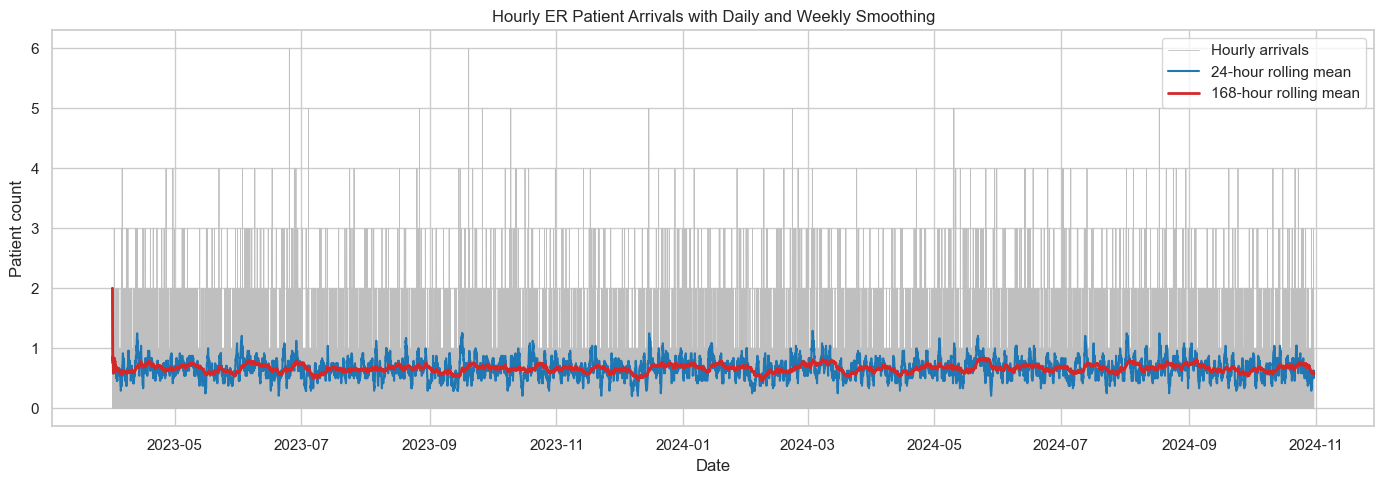

In [15]:
# Plot hourly arrivals with daily and weekly smoothing to reveal operational demand patterns.
volume_plot_df = analysis_df[["Patient_Count"]].copy()
volume_plot_df["Daily_Rolling_Mean"] = volume_plot_df["Patient_Count"].rolling(24, min_periods=1).mean()
volume_plot_df["Weekly_Rolling_Mean"] = volume_plot_df["Patient_Count"].rolling(168, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volume_plot_df.index, volume_plot_df["Patient_Count"], color="0.75", linewidth=0.6, label="Hourly arrivals")
ax.plot(volume_plot_df.index, volume_plot_df["Daily_Rolling_Mean"], color="#1f77b4", linewidth=1.5, label="24-hour rolling mean")
ax.plot(volume_plot_df.index, volume_plot_df["Weekly_Rolling_Mean"], color="#d62728", linewidth=2.0, label="168-hour rolling mean")
ax.set_title("Hourly ER Patient Arrivals with Daily and Weekly Smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("Patient count")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


> **Interpretation:** The raw hourly line shows short-term volatility, while the 24-hour and 168-hour rolling means separate day-to-day noise from broader demand movement. This supports using recent lags, daily lags, weekly lags, and rolling context in the forecasting feature set.


*Stationarity Tests*


In [16]:
# Test whether the hourly patient-arrival process behaves like a stationary time series.
stationarity_series = eda_series.dropna()

adf_result = adfuller(stationarity_series, autolag="AIC")
kpss_result = kpss(stationarity_series, regression="c", nlags="auto")

stationarity_summary = pd.DataFrame(
    {
        "Test": ["ADF", "KPSS"],
        "Null Hypothesis": ["Series has a unit root", "Series is level-stationary"],
        "Test Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]],
        "Used Lags": [adf_result[2], kpss_result[2]],
        "Decision at 0.05": [
            "Reject unit-root null" if adf_result[1] < 0.05 else "Fail to reject unit-root null",
            "Reject stationarity null" if kpss_result[1] < 0.05 else "Fail to reject stationarity null",
        ],
    }
)

display(stationarity_summary)

if stationarity_series.isna().any():
    raise ValueError("Stationarity series contains missing values.")


,Test,Null Hypothesis,Test Statistic,p-value,Used Lags,Decision at 0.05
0,ADF,Series has a unit root,-118.568209,0.0,0,Reject unit-root null
1,KPSS,Series is level-stationary,0.084340,0.1,7,Fail to reject stationarity null


> **Interpretation:** ADF and KPSS test opposite stationarity assumptions. Reading them together helps decide whether simple lag-based models can work directly on the hourly counts or whether additional transformations should be considered.


*STL Decomposition*


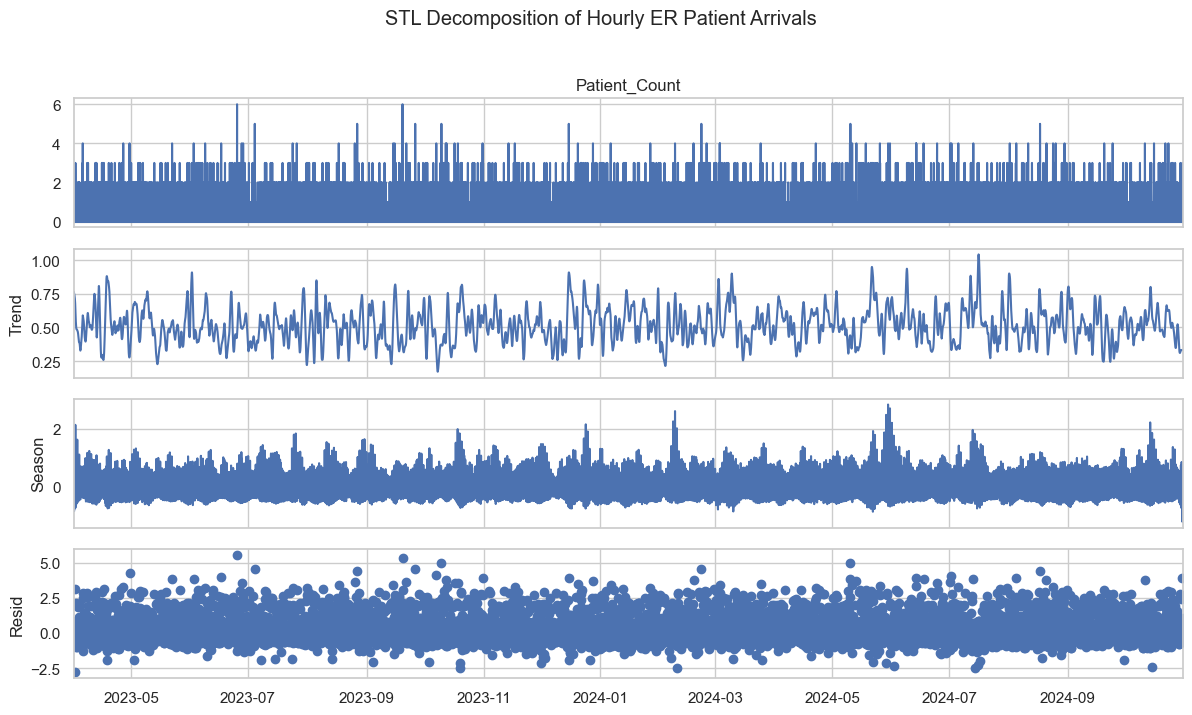

,Component,Mean,Std
0,Observed,0.663,0.815
1,Trend,0.515,0.130
2,Seasonal,-0.000,0.379
3,Residual,0.148,0.724


In [17]:
# Decompose the hourly patient-arrival series into daily trend, seasonal, and residual components.
stl_result = STL(eda_series, period=24, robust=True).fit()

fig = stl_result.plot()
fig.set_size_inches(12, 7)
fig.suptitle("STL Decomposition of Hourly ER Patient Arrivals", y=1.02)
plt.tight_layout()
plt.show()

stl_component_summary = pd.DataFrame(
    {
        "Component": ["Observed", "Trend", "Seasonal", "Residual"],
        "Mean": [
            eda_series.mean(),
            stl_result.trend.mean(),
            stl_result.seasonal.mean(),
            stl_result.resid.mean(),
        ],
        "Std": [
            eda_series.std(),
            stl_result.trend.std(),
            stl_result.seasonal.std(),
            stl_result.resid.std(),
        ],
    }
)

display(stl_component_summary.round(3))


> **Interpretation:** STL shows whether the hourly series is mostly trend, recurring daily pattern, or residual volatility. For short-term forecasting, a modest trend with visible seasonality supports lag and calendar features.


*Autocorrelation and Partial Autocorrelation*


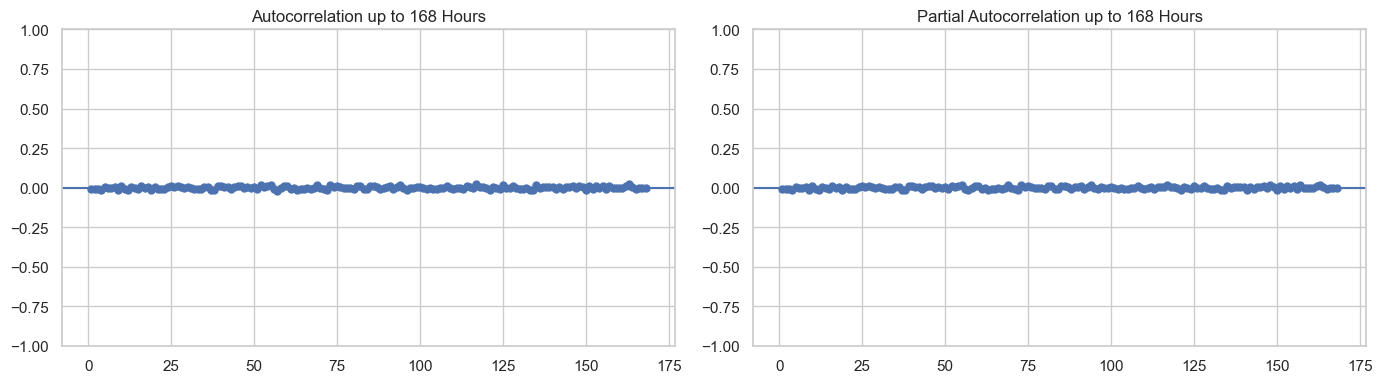

In [18]:
# Analyze temporal dependence through one full week of hourly lags.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(eda_series, lags=168, ax=axes[0], zero=False)
axes[0].set_title("Autocorrelation up to 168 Hours")
plot_pacf(eda_series, lags=168, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("Partial Autocorrelation up to 168 Hours")
plt.tight_layout()
plt.show()


> **Interpretation:** ACF and PACF identify which historical hours are most related to current arrivals. Peaks around 1-3 hours, 24 hours, or 168 hours justify short-term, daily, and weekly lag features.


## Feature Engineering & Temporal Embedding

This section starts from the clean regularized hourly demand series and creates modeling predictors in five groups: calendar features, external weather and flu-season features, leakage-safe lag features, rolling statistical features, and cyclical time encodings.


### Section 1: Add Calendar Features

Calendar features help the model learn recurring operational patterns: hour-of-day behavior, weekday/weekend differences, seasonal month effects, holiday demand changes, and whether a row was an observed arrival hour or an inserted zero-arrival hour.


In [19]:
# Add calendar predictors from the regularized hourly timestamp.
feature_engineering_df = analysis_df.reset_index().copy()
feature_engineering_df["DateTime_Hour"] = pd.to_datetime(feature_engineering_df["DateTime_Hour"])
feature_engineering_df = feature_engineering_df.sort_values("DateTime_Hour").reset_index(drop=True)

calendar = USFederalHolidayCalendar()
holiday_dates = pd.DatetimeIndex(
    calendar.holidays(
        start=feature_engineering_df["DateTime_Hour"].min().normalize(),
        end=feature_engineering_df["DateTime_Hour"].max().normalize(),
    )
).normalize()
day_after_holiday_dates = holiday_dates + pd.Timedelta(days=1)
feature_dates = feature_engineering_df["DateTime_Hour"].dt.normalize()

feature_engineering_df["Hour"] = feature_engineering_df["DateTime_Hour"].dt.hour
feature_engineering_df["Day_Of_Week"] = feature_engineering_df["DateTime_Hour"].dt.day_name()
feature_engineering_df["Is_Weekend"] = feature_engineering_df["DateTime_Hour"].dt.dayofweek >= 5
feature_engineering_df["Month"] = feature_engineering_df["DateTime_Hour"].dt.month_name()
feature_engineering_df["Holiday_Flag"] = feature_dates.isin(holiday_dates).astype(int)
feature_engineering_df["Day_After_Holiday"] = feature_dates.isin(day_after_holiday_dates).astype(int)

calendar_feature_columns = [
    "Hour",
    "Day_Of_Week",
    "Is_Weekend",
    "Month",
    "Holiday_Flag",
    "Day_After_Holiday",
    "Was_Observed_Hour",
]

calendar_feature_summary = pd.DataFrame(
    {
        "Feature": calendar_feature_columns,
        "Modeling Purpose": [
            "Learns within-day ER demand patterns",
            "Learns weekday-specific arrival behavior",
            "Captures weekend vs weekday differences",
            "Captures broad seasonal differences",
            "Captures public-holiday demand effects",
            "Captures rebound effects after holidays",
            "Identifies inserted zero-arrival hours after regularization",
        ],
        "Unique Values": [feature_engineering_df[column].nunique(dropna=False) for column in calendar_feature_columns],
    }
)

display(calendar_feature_summary)
display(feature_engineering_df[["DateTime_Hour", "Patient_Count"] + calendar_feature_columns].head())

if not feature_engineering_df["DateTime_Hour"].is_monotonic_increasing:
    raise ValueError("Calendar feature dataframe is not chronologically sorted.")
if feature_engineering_df[calendar_feature_columns].isna().any().any():
    raise ValueError("Calendar feature columns contain missing values.")


,Feature,Modeling Purpose,Unique Values
0,Hour,Learns within-day ER demand patterns,24
1,Day_Of_Week,Learns weekday-specific arrival behavior,7
2,Is_Weekend,Captures weekend vs weekday differences,2
3,Month,Captures broad seasonal differences,12
4,Holiday_Flag,Captures public-holiday demand effects,2
5,Day_After_Holiday,Captures rebound effects after holidays,2
6,Was_Observed_Hour,Identifies inserted zero-arrival hours after r...,2


,DateTime_Hour,Patient_Count,Hour,Day_Of_Week,Is_Weekend,Month,Holiday_Flag,Day_After_Holiday,Was_Observed_Hour
0,2023-04-01 01:00:00,2,1,Saturday,True,April,0,0,True
1,2023-04-01 02:00:00,1,2,Saturday,True,April,0,0,True
2,2023-04-01 03:00:00,0,3,Saturday,True,April,0,0,False
3,2023-04-01 04:00:00,1,4,Saturday,True,April,0,0,True
4,2023-04-01 05:00:00,0,5,Saturday,True,April,0,0,False


### Section 2: Add External Features

External features add context that is not visible in patient counts alone. Flu season can capture respiratory pressure, while temperature, humidity, rainfall, and extreme weather can help models identify demand shifts related to environmental conditions.


In [20]:
# Add flu-season and Los Angeles weather predictors from the cached Open-Meteo hourly file.
weather_path = (Path("Notebook/data") if Path("Notebook/data").exists() else Path("data")) / "weather_hourly_los_angeles.csv"
weather_columns = [
    "Temperature_F",
    "Temperature_Change_1h_F",
    "Humidity_Pct",
    "Rainfall_In",
    "Extreme_Weather_Flag",
]


def load_or_fetch_los_angeles_weather(start_timestamp, end_timestamp, cache_path):
    """Return cached hourly LA weather, downloading it from Open-Meteo when missing."""
    cache_path = Path(cache_path)
    start_date = pd.Timestamp(start_timestamp).date().isoformat()
    end_date = pd.Timestamp(end_timestamp).date().isoformat()

    if cache_path.exists():
        weather_df = pd.read_csv(cache_path, parse_dates=["DateTime_Hour"])
        if weather_df["DateTime_Hour"].min() <= pd.Timestamp(start_timestamp) and weather_df["DateTime_Hour"].max() >= pd.Timestamp(end_timestamp):
            return weather_df

    params = {
        "latitude": 34.0522,
        "longitude": -118.2437,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": "temperature_2m,relative_humidity_2m,rain,weather_code",
        "temperature_unit": "fahrenheit",
        "precipitation_unit": "inch",
        "timezone": "America/Los_Angeles",
    }
    url = "https://archive-api.open-meteo.com/v1/archive?" + urlencode(params)
    with urlopen(url, timeout=60) as response:
        payload = json.loads(response.read().decode("utf-8"))

    hourly_weather = payload["hourly"]
    weather_df = pd.DataFrame(
        {
            "DateTime_Hour": pd.to_datetime(hourly_weather["time"]),
            "Temperature_F": hourly_weather["temperature_2m"],
            "Humidity_Pct": hourly_weather["relative_humidity_2m"],
            "Rainfall_In": hourly_weather["rain"],
            "Weather_Code": hourly_weather["weather_code"],
        }
    ).sort_values("DateTime_Hour")
    weather_df["Temperature_Change_1h_F"] = weather_df["Temperature_F"].diff().fillna(0).round(2)
    weather_df["Extreme_Weather_Flag"] = (
        (weather_df["Temperature_F"] >= 95)
        | (weather_df["Rainfall_In"] >= 0.25)
        | (weather_df["Temperature_Change_1h_F"].abs() >= 10)
    ).astype(int)
    weather_df = weather_df[
        [
            "DateTime_Hour",
            "Temperature_F",
            "Temperature_Change_1h_F",
            "Humidity_Pct",
            "Rainfall_In",
            "Extreme_Weather_Flag",
            "Weather_Code",
        ]
    ]
    weather_df.to_csv(cache_path, index=False)
    return weather_df


weather_hourly = load_or_fetch_los_angeles_weather(
    feature_engineering_df["DateTime_Hour"].min(),
    feature_engineering_df["DateTime_Hour"].max(),
    weather_path,
)

feature_engineering_df = feature_engineering_df.drop(columns=[column for column in weather_columns if column in feature_engineering_df.columns])
feature_engineering_df["Is_Flu_Season"] = feature_engineering_df["DateTime_Hour"].dt.month.isin([10, 11, 12, 1, 2, 3]).astype(int)
feature_engineering_df = feature_engineering_df.merge(
    weather_hourly[["DateTime_Hour"] + weather_columns],
    on="DateTime_Hour",
    how="left",
)

external_feature_columns = ["Is_Flu_Season"] + weather_columns
external_feature_summary = pd.DataFrame(
    {
        "Feature": external_feature_columns,
        "Modeling Purpose": [
            "Captures high respiratory-season pressure",
            "Captures heat-related demand changes",
            "Captures sudden hourly weather shifts",
            "Captures respiratory or comfort-related weather conditions",
            "Captures rain-related injury and transport effects",
            "Flags unusual weather conditions compactly",
        ],
        "Missing Values": [feature_engineering_df[column].isna().sum() for column in external_feature_columns],
        "Unique Values": [feature_engineering_df[column].nunique(dropna=False) for column in external_feature_columns],
    }
)

display(external_feature_summary)
display(feature_engineering_df[["DateTime_Hour", "Patient_Count"] + external_feature_columns].head())

if feature_engineering_df[external_feature_columns].isna().any().any():
    raise ValueError("External feature columns contain missing values after weather merge.")
if not feature_engineering_df["Extreme_Weather_Flag"].isin([0, 1]).all():
    raise ValueError("Extreme weather flag must contain only 0 and 1.")


,Feature,Modeling Purpose,Missing Values,Unique Values
0,Is_Flu_Season,Captures high respiratory-season pressure,0,2
1,Temperature_F,Captures heat-related demand changes,0,622
2,Temperature_Change_1h_F,Captures sudden hourly weather shifts,0,179
3,Humidity_Pct,Captures respiratory or comfort-related weathe...,0,97
4,Rainfall_In,Captures rain-related injury and transport eff...,0,76
5,Extreme_Weather_Flag,Flags unusual weather conditions compactly,0,2


,DateTime_Hour,Patient_Count,Is_Flu_Season,Temperature_F,Temperature_Change_1h_F,Humidity_Pct,Rainfall_In,Extreme_Weather_Flag
0,2023-04-01 01:00:00,2,0,49.5,-0.3,89,0.0,0
1,2023-04-01 02:00:00,1,0,50.4,0.9,82,0.0,0
2,2023-04-01 03:00:00,0,0,50.0,-0.4,82,0.0,0
3,2023-04-01 04:00:00,1,0,50.2,0.2,81,0.0,0
4,2023-04-01 05:00:00,0,0,47.8,-2.4,82,0.0,0


### Section 3: Add Lag Features

Lag features turn the time series into supervised-learning predictors. They help models learn short-term momentum, same-hour-yesterday behavior, and same-hour-last-week behavior without looking into the future.


In [21]:
# Create leakage-safe lag features from past patient counts.
lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168]
for lag in lag_hours:
    feature_engineering_df[f"Lag_{lag}h"] = feature_engineering_df["Patient_Count"].shift(lag)

lag_columns = [f"Lag_{lag}h" for lag in lag_hours]
lag_missing_summary = feature_engineering_df[lag_columns].isna().sum().to_frame("Missing_Rows")

lag_feature_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows before dropping lag nulls",
            "Lag predictor columns",
            "Earliest timestamp",
            "Latest timestamp",
        ],
        "Value": [
            len(feature_engineering_df),
            len(lag_columns),
            feature_engineering_df["DateTime_Hour"].min(),
            feature_engineering_df["DateTime_Hour"].max(),
        ],
    }
)

lag_purpose_summary = pd.DataFrame(
    {
        "Lag Group": ["Recent lags", "Daily lags", "Weekly lag"],
        "Columns": ["Lag_1h, Lag_2h, Lag_3h, Lag_6h, Lag_12h", "Lag_24h, Lag_48h, Lag_72h", "Lag_168h"],
        "Modeling Purpose": [
            "Capture short-term patient-flow momentum",
            "Capture same-hour patterns across recent days",
            "Capture same-hour-last-week behavior",
        ],
    }
)

display(lag_feature_summary)
display(lag_purpose_summary)
display(lag_missing_summary)
display(feature_engineering_df[["DateTime_Hour", "Patient_Count"] + lag_columns].head(172))

expected_missing_counts = {f"Lag_{lag}h": lag for lag in lag_hours}
actual_missing_counts = feature_engineering_df[lag_columns].isna().sum().to_dict()
if actual_missing_counts != expected_missing_counts:
    raise ValueError(f"Unexpected lag missing counts: {actual_missing_counts}")


,Metric,Value
0,Rows before dropping lag nulls,13895
1,Lag predictor columns,9
2,Earliest timestamp,2023-04-01 01:00:00
3,Latest timestamp,2024-10-30 23:00:00


,Lag Group,Columns,Modeling Purpose
0,Recent lags,"Lag_1h, Lag_2h, Lag_3h, Lag_6h, Lag_12h",Capture short-term patient-flow momentum
1,Daily lags,"Lag_24h, Lag_48h, Lag_72h",Capture same-hour patterns across recent days
2,Weekly lag,Lag_168h,Capture same-hour-last-week behavior


,Missing_Rows
Lag_1h,1
Lag_2h,2
Lag_3h,3
Lag_6h,6
Lag_12h,12
Lag_24h,24
Lag_48h,48
Lag_72h,72
Lag_168h,168


,DateTime_Hour,Patient_Count,Lag_1h,Lag_2h,Lag_3h,Lag_6h,Lag_12h,Lag_24h,Lag_48h,Lag_72h,Lag_168h
0,2023-04-01 01:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-04-01 02:00:00,1,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-04-01 03:00:00,0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-04-01 04:00:00,1,0.0,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-04-01 05:00:00,0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
167,2023-04-08 00:00:00,3,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,NaN
168,2023-04-08 01:00:00,1,3.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0
169,2023-04-08 02:00:00,1,1.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0
170,2023-04-08 03:00:00,2,1.0,1.0,3.0,1.0,0.0,2.0,0.0,1.0,0.0


### Section 4: Add Rolling Window Features

Rolling features summarize recent demand level and volatility. They are shifted by one hour so the model only uses information available before the forecast origin.


In [22]:
# Create leakage-safe rolling statistical features from past patient counts.
shifted_patient_count = feature_engineering_df["Patient_Count"].shift(1)
rolling_mean_windows = [3, 6, 24, 168]
rolling_std_windows = [24, 168]

for window in rolling_mean_windows:
    feature_engineering_df[f"Rolling_Mean_{window}h"] = shifted_patient_count.rolling(window).mean()
for window in rolling_std_windows:
    feature_engineering_df[f"Rolling_Std_{window}h"] = shifted_patient_count.rolling(window).std()

rolling_feature_columns = [f"Rolling_Mean_{window}h" for window in rolling_mean_windows] + [
    f"Rolling_Std_{window}h" for window in rolling_std_windows
]
rolling_missing_summary = feature_engineering_df[rolling_feature_columns].isna().sum().to_frame("Missing_Rows")
rolling_purpose_summary = pd.DataFrame(
    {
        "Feature Group": ["Rolling means", "Rolling standard deviations"],
        "Columns": [
            "Rolling_Mean_3h, Rolling_Mean_6h, Rolling_Mean_24h, Rolling_Mean_168h",
            "Rolling_Std_24h, Rolling_Std_168h",
        ],
        "Modeling Purpose": [
            "Summarize recent demand level across short, daily, and weekly windows",
            "Summarize recent demand volatility across daily and weekly windows",
        ],
    }
)

display(rolling_purpose_summary)
display(rolling_missing_summary)
display(feature_engineering_df[["DateTime_Hour", "Patient_Count"] + rolling_feature_columns].head(172))

expected_rolling_missing_counts = {
    "Rolling_Mean_3h": 3,
    "Rolling_Mean_6h": 6,
    "Rolling_Mean_24h": 24,
    "Rolling_Mean_168h": 168,
    "Rolling_Std_24h": 24,
    "Rolling_Std_168h": 168,
}
actual_rolling_missing_counts = feature_engineering_df[rolling_feature_columns].isna().sum().to_dict()
if actual_rolling_missing_counts != expected_rolling_missing_counts:
    raise ValueError(f"Unexpected rolling missing counts: {actual_rolling_missing_counts}")

# Spot-check that rolling features use only prior patient counts.
row_position = 168
expected_rolling_24h = feature_engineering_df.loc[row_position - 24 : row_position - 1, "Patient_Count"].mean()
actual_rolling_24h = feature_engineering_df.loc[row_position, "Rolling_Mean_24h"]
if not np.isclose(actual_rolling_24h, expected_rolling_24h):
    raise ValueError("Rolling_Mean_24h does not match shifted prior-hour calculation.")


,Feature Group,Columns,Modeling Purpose
0,Rolling means,"Rolling_Mean_3h, Rolling_Mean_6h, Rolling_Mean...","Summarize recent demand level across short, da..."
1,Rolling standard deviations,"Rolling_Std_24h, Rolling_Std_168h",Summarize recent demand volatility across dail...


,Missing_Rows
Rolling_Mean_3h,3
Rolling_Mean_6h,6
Rolling_Mean_24h,24
Rolling_Mean_168h,168
Rolling_Std_24h,24
Rolling_Std_168h,168


,DateTime_Hour,Patient_Count,Rolling_Mean_3h,Rolling_Mean_6h,Rolling_Mean_24h,Rolling_Mean_168h,Rolling_Std_24h,Rolling_Std_168h
0,2023-04-01 01:00:00,2,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-04-01 02:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-04-01 03:00:00,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-04-01 04:00:00,1,1.000000,NaN,NaN,NaN,NaN,NaN
4,2023-04-01 05:00:00,0,0.666667,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
167,2023-04-08 00:00:00,3,1.000000,0.833333,0.458333,NaN,0.658005,NaN
168,2023-04-08 01:00:00,1,1.666667,1.333333,0.583333,0.607143,0.829702,0.774100
169,2023-04-08 02:00:00,1,1.666667,1.333333,0.625000,0.601190,0.824226,0.767139
170,2023-04-08 03:00:00,2,1.666667,1.333333,0.666667,0.601190,0.816497,0.767139


### Section 5: Add Cyclical Time Encodings

Cyclical encodings preserve circular time relationships. They help models understand that hour 23 is close to hour 0, and that December and January are seasonally close.


In [23]:
# Encode repeating time fields with sine and cosine transformations.
feature_engineering_df["Day_Of_Week_Num"] = feature_engineering_df["DateTime_Hour"].dt.dayofweek
feature_engineering_df["Month_Num"] = feature_engineering_df["DateTime_Hour"].dt.month

feature_engineering_df["Hour_Sin"] = np.sin(2 * np.pi * feature_engineering_df["Hour"] / 24)
feature_engineering_df["Hour_Cos"] = np.cos(2 * np.pi * feature_engineering_df["Hour"] / 24)
feature_engineering_df["Day_Of_Week_Sin"] = np.sin(2 * np.pi * feature_engineering_df["Day_Of_Week_Num"] / 7)
feature_engineering_df["Day_Of_Week_Cos"] = np.cos(2 * np.pi * feature_engineering_df["Day_Of_Week_Num"] / 7)
feature_engineering_df["Month_Sin"] = np.sin(2 * np.pi * feature_engineering_df["Month_Num"] / 12)
feature_engineering_df["Month_Cos"] = np.cos(2 * np.pi * feature_engineering_df["Month_Num"] / 12)

cyclical_feature_columns = [
    "Hour_Sin",
    "Hour_Cos",
    "Day_Of_Week_Sin",
    "Day_Of_Week_Cos",
    "Month_Sin",
    "Month_Cos",
]
cyclical_summary = pd.DataFrame(
    {
        "Feature": cyclical_feature_columns,
        "Minimum": [feature_engineering_df[column].min() for column in cyclical_feature_columns],
        "Maximum": [feature_engineering_df[column].max() for column in cyclical_feature_columns],
        "Missing Values": [feature_engineering_df[column].isna().sum() for column in cyclical_feature_columns],
    }
)

display(cyclical_summary.round(3))
display(feature_engineering_df[["DateTime_Hour", "Hour", "Day_Of_Week", "Month"] + cyclical_feature_columns].head())

if feature_engineering_df[cyclical_feature_columns].isna().any().any():
    raise ValueError("Cyclical time encoding columns contain missing values.")
if not feature_engineering_df[cyclical_feature_columns].apply(lambda column: column.between(-1, 1).all()).all():
    raise ValueError("Cyclical time encoding values must be between -1 and 1.")


,Feature,Minimum,Maximum,Missing Values
0,Hour_Sin,-1.000,1.000,0
1,Hour_Cos,-1.000,1.000,0
2,Day_Of_Week_Sin,-0.975,0.975,0
3,Day_Of_Week_Cos,-0.901,1.000,0
4,Month_Sin,-1.000,1.000,0
5,Month_Cos,-1.000,1.000,0


,DateTime_Hour,Hour,Day_Of_Week,Month,Hour_Sin,Hour_Cos,Day_Of_Week_Sin,Day_Of_Week_Cos,Month_Sin,Month_Cos
0,2023-04-01 01:00:00,1,Saturday,April,0.258819,0.965926,-0.974928,-0.222521,0.866025,-0.5
1,2023-04-01 02:00:00,2,Saturday,April,0.500000,0.866025,-0.974928,-0.222521,0.866025,-0.5
2,2023-04-01 03:00:00,3,Saturday,April,0.707107,0.707107,-0.974928,-0.222521,0.866025,-0.5
3,2023-04-01 04:00:00,4,Saturday,April,0.866025,0.500000,-0.974928,-0.222521,0.866025,-0.5
4,2023-04-01 05:00:00,5,Saturday,April,0.965926,0.258819,-0.974928,-0.222521,0.866025,-0.5


### Final Modeling Feature Table

This step combines all engineered predictor groups and drops only the rows that do not yet have enough historical context for lag and rolling features.


In [24]:
# Create the final modeling-ready feature table.
all_feature_columns = (
    calendar_feature_columns
    + external_feature_columns
    + lag_columns
    + rolling_feature_columns
    + cyclical_feature_columns
)

feature_modeling_df = feature_engineering_df.dropna(subset=all_feature_columns).reset_index(drop=True)

feature_modeling_summary = pd.DataFrame(
    {
        "Metric": [
            "Rows before dropping feature nulls",
            "Rows after dropping feature nulls",
            "Predictor columns",
            "Earliest usable timestamp",
            "Latest usable timestamp",
            "Missing predictor values",
        ],
        "Value": [
            len(feature_engineering_df),
            len(feature_modeling_df),
            len(all_feature_columns),
            feature_modeling_df["DateTime_Hour"].min(),
            feature_modeling_df["DateTime_Hour"].max(),
            int(feature_modeling_df[all_feature_columns].isna().sum().sum()),
        ],
    }
)

display(feature_modeling_summary)
display(feature_modeling_df[["DateTime_Hour", "Patient_Count"] + all_feature_columns[:10]].head())

if not feature_modeling_df["DateTime_Hour"].is_monotonic_increasing:
    raise ValueError("Feature modeling dataframe is not chronologically sorted.")
if feature_modeling_df[all_feature_columns].isna().any().any():
    raise ValueError("Feature modeling dataframe contains missing predictor values.")
if len(feature_engineering_df) - len(feature_modeling_df) != 168:
    raise ValueError("Feature modeling dataframe should drop exactly the first 168 rows.")


,Metric,Value
0,Rows before dropping feature nulls,13895
1,Rows after dropping feature nulls,13727
2,Predictor columns,34
3,Earliest usable timestamp,2023-04-08 01:00:00
4,Latest usable timestamp,2024-10-30 23:00:00
5,Missing predictor values,0


,DateTime_Hour,Patient_Count,Hour,Day_Of_Week,Is_Weekend,Month,Holiday_Flag,Day_After_Holiday,Was_Observed_Hour,Is_Flu_Season,Temperature_F,Temperature_Change_1h_F
0,2023-04-08 01:00:00,1,1,Saturday,True,April,0,0,True,0,50.0,-1.0
1,2023-04-08 02:00:00,1,2,Saturday,True,April,0,0,True,0,49.2,-0.8
2,2023-04-08 03:00:00,2,3,Saturday,True,April,0,0,True,0,49.0,-0.2
3,2023-04-08 04:00:00,0,4,Saturday,True,April,0,0,False,0,49.1,0.1
4,2023-04-08 05:00:00,0,5,Saturday,True,April,0,0,False,0,49.7,0.6


> **Interpretation:** The clean base CSVs preserve the hourly target and operational outcomes, while `feature_engineering_df` contains all engineered predictors and `feature_modeling_df` is the complete modeling-ready table. Calendar, external, lag, rolling, and cyclical features now give models multiple ways to learn recurring demand structure without polluting the base data files.


In [25]:
feature_modeling_df.head()


,DateTime_Hour,Patient_Count,Avg_Waittime,Admission_Count,Was_Observed_Hour,Hour,Day_Of_Week,Is_Weekend,Month,Holiday_Flag,...,Rolling_Std_24h,Rolling_Std_168h,Day_Of_Week_Num,Month_Num,Hour_Sin,Hour_Cos,Day_Of_Week_Sin,Day_Of_Week_Cos,Month_Sin,Month_Cos
0,2023-04-08 01:00:00,1,32.0,0,True,1,Saturday,True,April,0,...,0.829702,0.774100,5,4,0.258819,0.965926,-0.974928,-0.222521,0.866025,-0.5
1,2023-04-08 02:00:00,1,22.0,0,True,2,Saturday,True,April,0,...,0.824226,0.767139,5,4,0.500000,0.866025,-0.974928,-0.222521,0.866025,-0.5
2,2023-04-08 03:00:00,2,23.0,2,True,3,Saturday,True,April,0,...,0.816497,0.767139,5,4,0.707107,0.707107,-0.974928,-0.222521,0.866025,-0.5
3,2023-04-08 04:00:00,0,NaN,0,False,4,Saturday,True,April,0,...,0.816497,0.773247,5,4,0.866025,0.500000,-0.974928,-0.222521,0.866025,-0.5
4,2023-04-08 05:00:00,0,NaN,0,False,5,Saturday,True,April,0,...,0.816497,0.774100,5,4,0.965926,0.258819,-0.974928,-0.222521,0.866025,-0.5


## Short-Term Forecasting Model Suite

Before training, this section defines a model suite that moves from simple and interpretable methods to more flexible machine-learning methods. The goal is not only to find the lowest error, but also to understand whether advanced models are truly better than simple time-series logic.

The models trained below are:

- **Seasonal naive and moving-average benchmarks:** These are simple baselines. They answer: can we do reasonably well by using the current hour, the same hour yesterday, the same hour last week, or the recent 24-hour average
- **Poisson regression:** Patient arrivals are count data, so Poisson regression gives an interpretable count-aware model for demand drivers.
- **Ridge regression:** This is a regularized linear model. It provides a stable interpretable baseline when many engineered predictors are used.
- **SARIMAX:** This classical time-series regression model captures temporal dependence and daily seasonality while also allowing exogenous predictors.
- **LightGBM / HistGradientBoosting:** These nonlinear tabular models can learn interactions between lag features, rolling demand context, calendar effects, flu season, and weather.

All models are evaluated on the same chronological test set using RMSE, MAE, zero-safe MAPE, mean bias, and underprediction rate.


### Forecast Targets and Chronological Split

The targets represent future patient volume at 1, 6, 24, and 72 hours. The split stays chronological so future hours never leak into model training.


In [26]:
# Create supervised forecasting targets and chronological train/validation/test splits.
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX

try:
    import lightgbm as lgb
except ImportError:
    lgb = None

forecast_horizons = {1: "Target_1h", 6: "Target_6h", 24: "Target_24h", 72: "Target_72h"}
modeling_supervised_df = feature_modeling_df.copy()

for horizon, target_column in forecast_horizons.items():
    modeling_supervised_df[target_column] = modeling_supervised_df["Patient_Count"].shift(-horizon)

# Validate target construction before dropping horizon-tail rows.
for horizon, target_column in forecast_horizons.items():
    comparison = modeling_supervised_df[target_column].dropna().reset_index(drop=True)
    expected = feature_modeling_df["Patient_Count"].shift(-horizon).dropna().reset_index(drop=True)
    if not comparison.equals(expected):
        raise ValueError(f"{target_column} was not shifted correctly.")

target_columns = list(forecast_horizons.values())
modeling_supervised_df = modeling_supervised_df.dropna(subset=target_columns).reset_index(drop=True)

# Convert readable categorical fields to numeric model inputs while preserving all engineered predictors.
X_encoded = pd.get_dummies(modeling_supervised_df[all_feature_columns], drop_first=False, dtype=float)
y_targets = modeling_supervised_df[target_columns]
forecast_origins = modeling_supervised_df["DateTime_Hour"]

train_end = int(len(modeling_supervised_df) * 0.70)
validation_end = int(len(modeling_supervised_df) * 0.85)

X_train = X_encoded.iloc[:train_end]
X_val = X_encoded.iloc[train_end:validation_end]
X_train_val = X_encoded.iloc[:validation_end]
X_test = X_encoded.iloc[validation_end:]

y_train = y_targets.iloc[:train_end]
y_val = y_targets.iloc[train_end:validation_end]
y_train_val = y_targets.iloc[:validation_end]
y_test = y_targets.iloc[validation_end:]

date_train = forecast_origins.iloc[:train_end]
date_val = forecast_origins.iloc[train_end:validation_end]
date_test = forecast_origins.iloc[validation_end:]

split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Rows": [len(X_train), len(X_val), len(X_test)],
        "Start": [date_train.min(), date_val.min(), date_test.min()],
        "End": [date_train.max(), date_val.max(), date_test.max()],
    }
)

display(split_summary)

if not (date_train.max() < date_val.min() < date_test.min()):
    raise ValueError("Chronological split boundaries overlap or are out of order.")
if X_encoded.isna().any().any() or y_targets.isna().any().any():
    raise ValueError("Modeling matrix contains missing predictor or target values.")
if X_test.empty:
    raise ValueError("Test split is empty.")


,Split,Rows,Start,End
0,Train,9558,2023-04-08 01:00:00,2024-05-10 06:00:00
1,Validation,2048,2024-05-10 07:00:00,2024-08-03 14:00:00
2,Test,2049,2024-08-03 15:00:00,2024-10-27 23:00:00


### Shared Evaluation Metrics

All models use the same metrics: RMSE, MAE, zero-safe MAPE, mean bias, and underprediction rate.


In [27]:
# Define shared metrics and prediction storage.
def zero_safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero_mask = y_true != 0
    if not nonzero_mask.any():
        return np.nan
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    residuals = y_true - y_pred
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": zero_safe_mape(y_true, y_pred),
        "Mean_Bias": residuals.mean(),
        "Underprediction_Rate": (residuals > 0).mean(),
    }


def clip_nonnegative(predictions):
    return np.clip(np.asarray(predictions, dtype=float), 0, None)


metric_frames = []
prediction_store = {}
model_notes = []


### Simple Benchmarks

Benchmarks establish the performance floor: current-hour persistence, same-hour yesterday, same-hour last week, and recent 24-hour average.


In [28]:
# Build simple benchmark forecasts for every horizon.
baseline_predictions = {
    "Persistence": pd.DataFrame(index=y_test.index),
    "Seasonal Naive 24h": pd.DataFrame(index=y_test.index),
    "Seasonal Naive 168h": pd.DataFrame(index=y_test.index),
    "Moving Average 24h": pd.DataFrame(index=y_test.index),
}

for target_column in target_columns:
    baseline_predictions["Persistence"][target_column] = modeling_supervised_df.loc[y_test.index, "Patient_Count"].values
    baseline_predictions["Seasonal Naive 24h"][target_column] = modeling_supervised_df.loc[y_test.index, "Lag_24h"].values
    baseline_predictions["Seasonal Naive 168h"][target_column] = modeling_supervised_df.loc[y_test.index, "Lag_168h"].values
    baseline_predictions["Moving Average 24h"][target_column] = modeling_supervised_df.loc[y_test.index, "Rolling_Mean_24h"].values

benchmark_rows = []
for model_name, predictions in baseline_predictions.items():
    predictions = predictions.clip(lower=0)
    prediction_store[model_name] = predictions
    for horizon, target_column in forecast_horizons.items():
        benchmark_rows.append(
            {
                "Model": model_name,
                "Model_Group": "Simple Benchmark",
                "Horizon": f"{horizon}h",
                **regression_metrics(y_test[target_column], predictions[target_column]),
            }
        )

benchmark_metrics_df = pd.DataFrame(benchmark_rows)
metric_frames.append(benchmark_metrics_df)
display(benchmark_metrics_df.sort_values(["Horizon", "RMSE"]))

for model_name, predictions in baseline_predictions.items():
    if not predictions.index.equals(y_test.index):
        raise ValueError(f"{model_name} predictions are not aligned with the test index.")
    if (predictions < 0).any().any():
        raise ValueError(f"{model_name} produced negative predictions.")


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate
12,Moving Average 24h,Simple Benchmark,1h,0.840760,0.696153,44.604846,-0.001383,0.473402
0,Persistence,Simple Benchmark,1h,1.163752,0.836994,71.907164,-0.000488,0.311371
4,Seasonal Naive 24h,Simple Benchmark,1h,1.167729,0.820888,70.475950,-0.003904,0.299658
8,Seasonal Naive 168h,Simple Benchmark,1h,1.179374,0.833577,70.484359,-0.007809,0.298682
14,Moving Average 24h,Simple Benchmark,24h,0.837513,0.692452,44.273348,0.000081,0.472914
2,Persistence,Simple Benchmark,24h,1.158077,0.826745,71.671697,0.000976,0.308931
6,Seasonal Naive 24h,Simple Benchmark,24h,1.168356,0.844802,73.390342,-0.002440,0.311371
10,Seasonal Naive 168h,Simple Benchmark,24h,1.189879,0.855539,70.724346,-0.006345,0.313812
13,Moving Average 24h,Simple Benchmark,6h,0.841075,0.696885,44.712832,-0.000895,0.471449
5,Seasonal Naive 24h,Simple Benchmark,6h,1.165428,0.836018,71.779347,-0.003416,0.314300


### Interpretable Regression Models

Poisson regression is count-aware, while Ridge regression gives a regularized linear benchmark. Their coefficients help explain demand drivers.


In [29]:
# Train interpretable regression models for each forecast horizon.
regression_model_specs = {
    "Poisson Regression": make_pipeline(StandardScaler(), PoissonRegressor(alpha=0.1, max_iter=1000)),
    "Ridge Regression": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
}

regression_rows = []
regression_coefficient_rows = []

for model_name, model_template in regression_model_specs.items():
    model_predictions = pd.DataFrame(index=y_test.index)
    for horizon, target_column in forecast_horizons.items():
        model = model_template
        model.fit(X_train_val, y_train_val[target_column])
        predictions = clip_nonnegative(model.predict(X_test))
        model_predictions[target_column] = predictions
        regression_rows.append(
            {
                "Model": model_name,
                "Model_Group": "Interpretable Regression",
                "Horizon": f"{horizon}h",
                **regression_metrics(y_test[target_column], predictions),
            }
        )

        final_estimator = model.named_steps[list(model.named_steps.keys())[-1]]
        if hasattr(final_estimator, "coef_"):
            coefficient_df = pd.DataFrame(
                {
                    "Feature": X_encoded.columns,
                    "Coefficient": final_estimator.coef_,
                    "Model": model_name,
                    "Horizon": f"{horizon}h",
                }
            )
            coefficient_df["Abs_Coefficient"] = coefficient_df["Coefficient"].abs()
            regression_coefficient_rows.append(coefficient_df.sort_values("Abs_Coefficient", ascending=False).head(10))

    prediction_store[model_name] = model_predictions
    if (model_predictions < 0).any().any():
        raise ValueError(f"{model_name} produced negative predictions after clipping.")

regression_metrics_df = pd.DataFrame(regression_rows)
metric_frames.append(regression_metrics_df)
display(regression_metrics_df.sort_values(["Horizon", "RMSE"]))

if regression_coefficient_rows:
    regression_coefficients_df = pd.concat(regression_coefficient_rows, ignore_index=True)
    display(regression_coefficients_df.head(20))


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate
0,Poisson Regression,Interpretable Regression,1h,0.821406,0.689766,44.876873,0.007978,0.483651
4,Ridge Regression,Interpretable Regression,1h,0.821877,0.689764,44.964019,0.008973,0.483651
2,Poisson Regression,Interpretable Regression,24h,0.822195,0.689900,45.840029,0.020129,0.485115
6,Ridge Regression,Interpretable Regression,24h,0.823211,0.689744,46.220875,0.024580,0.485115
1,Poisson Regression,Interpretable Regression,6h,0.822933,0.691785,44.687824,0.004212,0.483651
5,Ridge Regression,Interpretable Regression,6h,0.823399,0.691862,44.683377,0.004079,0.483651
3,Poisson Regression,Interpretable Regression,72h,0.819076,0.688401,45.188021,0.009305,0.481698
7,Ridge Regression,Interpretable Regression,72h,0.819620,0.688198,45.287491,0.010795,0.481698


,Feature,Coefficient,Model,Horizon,Abs_Coefficient
0,Day_After_Holiday,-0.024709,Poisson Regression,1h,0.024709
1,Hour,0.022562,Poisson Regression,1h,0.022562
2,Humidity_Pct,0.018421,Poisson Regression,1h,0.018421
3,Month_February,-0.017631,Poisson Regression,1h,0.017631
4,Holiday_Flag,-0.017228,Poisson Regression,1h,0.017228
5,Rolling_Mean_24h,-0.016375,Poisson Regression,1h,0.016375
6,Hour_Sin,0.015066,Poisson Regression,1h,0.015066
7,Lag_3h,-0.014634,Poisson Regression,1h,0.014634
8,Lag_24h,0.013571,Poisson Regression,1h,0.013571
9,Month_July,-0.012956,Poisson Regression,1h,0.012956


### Compact SARIMAX Time-Series Regression

SARIMAX is fit for the 1-hour horizon as a classical time-series comparison. It uses a compact daily seasonal structure to avoid an expensive hourly weekly model.


In [30]:
# Fit a compact SARIMAX model for the 1-hour horizon.
sarimax_target_column = "Target_1h"
sarimax_exog_columns = [
    "Hour_Sin",
    "Hour_Cos",
    "Day_Of_Week_Sin",
    "Day_Of_Week_Cos",
    "Is_Weekend",
    "Is_Flu_Season",
    "Temperature_F",
    "Rainfall_In",
    "Extreme_Weather_Flag",
    "Rolling_Mean_24h",
]
sarimax_exog_columns = [column for column in sarimax_exog_columns if column in modeling_supervised_df.columns]

sarimax_train_val = modeling_supervised_df.iloc[:validation_end].copy()
sarimax_test = modeling_supervised_df.iloc[validation_end:].copy()

# Use a recent tail of the training period to keep the classical model computationally compact.
sarimax_training_tail = min(3000, len(sarimax_train_val))
sarimax_train_tail = sarimax_train_val.tail(sarimax_training_tail)

try:
    sarimax_train_exog = sarimax_train_tail[sarimax_exog_columns].astype(float)
    sarimax_test_exog = sarimax_test[sarimax_exog_columns].astype(float)
    sarimax_train_endog = sarimax_train_tail[sarimax_target_column].astype(float)

    sarimax_model = SARIMAX(
        endog=sarimax_train_endog,
        exog=sarimax_train_exog,
        order=(1, 0, 0),
        seasonal_order=(1, 0, 0, 24),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarimax_result = sarimax_model.fit(disp=False, maxiter=25)
    sarimax_forecast = sarimax_result.forecast(
        steps=len(sarimax_test),
        exog=sarimax_test_exog,
    )
    sarimax_predictions = pd.DataFrame(index=y_test.index)
    sarimax_predictions[sarimax_target_column] = clip_nonnegative(sarimax_forecast)
    prediction_store["SARIMAX"] = sarimax_predictions
    sarimax_metrics_df = pd.DataFrame(
        [
            {
                "Model": "SARIMAX",
                "Model_Group": "Time-Series Regression",
                "Horizon": "1h",
                **regression_metrics(y_test[sarimax_target_column], sarimax_predictions[sarimax_target_column]),
            }
        ]
    )
    metric_frames.append(sarimax_metrics_df)
    display(sarimax_metrics_df)
except Exception as error:
    model_notes.append(f"SARIMAX skipped: {error}")
    sarimax_metrics_df = pd.DataFrame()
    print(model_notes[-1])


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate
0,SARIMAX,Time-Series Regression,1h,0.825899,0.693118,39.654683,-0.056182,0.483651


### Nonlinear Machine-Learning Models

LightGBM captures nonlinear interactions among lag, rolling, calendar, weather, and cyclical features. If LightGBM is unavailable, HistGradientBoosting provides a sklearn fallback.


In [31]:
# Train nonlinear machine-learning models for each forecast horizon.
ml_rows = []
ml_importance_rows = []
ml_model_name = "LightGBM" if lgb is not None else "HistGradientBoosting"
ml_predictions = pd.DataFrame(index=y_test.index)

for horizon, target_column in forecast_horizons.items():
    if lgb is not None:
        model = lgb.LGBMRegressor(
            objective="regression",
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_samples=25,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
        model.fit(
            X_train,
            y_train[target_column],
            eval_set=[(X_val, y_val[target_column])],
            eval_metric="l2",
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)],
        )
        predictions = clip_nonnegative(model.predict(X_test))
        importance_df = pd.DataFrame(
            {
                "Feature": X_encoded.columns,
                "Importance": model.feature_importances_,
                "Horizon": f"{horizon}h",
            }
        ).sort_values("Importance", ascending=False).head(12)
        ml_importance_rows.append(importance_df)
    else:
        model = HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_iter=250,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_val, y_train_val[target_column])
        predictions = clip_nonnegative(model.predict(X_test))

    ml_predictions[target_column] = predictions
    ml_rows.append(
        {
            "Model": ml_model_name,
            "Model_Group": "Nonlinear ML",
            "Horizon": f"{horizon}h",
            **regression_metrics(y_test[target_column], predictions),
        }
    )

prediction_store[ml_model_name] = ml_predictions
ml_metrics_df = pd.DataFrame(ml_rows)
metric_frames.append(ml_metrics_df)
display(ml_metrics_df.sort_values(["Horizon", "RMSE"]))

if ml_importance_rows:
    ml_feature_importance_df = pd.concat(ml_importance_rows, ignore_index=True)
    display(ml_feature_importance_df)

if (ml_predictions < 0).any().any():
    raise ValueError(f"{ml_model_name} produced negative predictions after clipping.")


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate
0,LightGBM,Nonlinear ML,1h,0.821846,0.690580,45.016546,0.009266,0.483651
2,LightGBM,Nonlinear ML,24h,0.822970,0.689922,45.632163,0.018104,0.485115
1,LightGBM,Nonlinear ML,6h,0.822272,0.691146,44.987382,0.008867,0.483651
3,LightGBM,Nonlinear ML,72h,0.819534,0.689846,45.017101,0.006000,0.481698


,Feature,Importance,Horizon
0,Temperature_F,8,1h
1,Rolling_Std_24h,7,1h
2,Rolling_Mean_168h,6,1h
3,Humidity_Pct,4,1h
4,Rolling_Std_168h,3,1h
5,Rainfall_In,3,1h
6,Lag_24h,2,1h
7,Temperature_Change_1h_F,2,1h
8,Lag_72h,2,1h
9,Hour,2,1h


### Model Comparison and Best-Model Plots

The combined table ranks all available models by RMSE within each horizon, then plots actual versus predicted counts for the best model at each horizon.


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate,Rank_By_RMSE
0,Poisson Regression,Interpretable Regression,1h,0.821406,0.689766,44.876873,0.007978,0.483651,1.0
1,LightGBM,Nonlinear ML,1h,0.821846,0.690580,45.016546,0.009266,0.483651,2.0
2,Ridge Regression,Interpretable Regression,1h,0.821877,0.689764,44.964019,0.008973,0.483651,3.0
3,SARIMAX,Time-Series Regression,1h,0.825899,0.693118,39.654683,-0.056182,0.483651,4.0
4,Moving Average 24h,Simple Benchmark,1h,0.840760,0.696153,44.604846,-0.001383,0.473402,5.0
5,Persistence,Simple Benchmark,1h,1.163752,0.836994,71.907164,-0.000488,0.311371,6.0
6,Seasonal Naive 24h,Simple Benchmark,1h,1.167729,0.820888,70.475950,-0.003904,0.299658,7.0
7,Seasonal Naive 168h,Simple Benchmark,1h,1.179374,0.833577,70.484359,-0.007809,0.298682,8.0
8,Poisson Regression,Interpretable Regression,24h,0.822195,0.689900,45.840029,0.020129,0.485115,1.0
9,LightGBM,Nonlinear ML,24h,0.822970,0.689922,45.632163,0.018104,0.485115,2.0



Best model by horizon:


,Model,Model_Group,Horizon,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate,Rank_By_RMSE
0,Poisson Regression,Interpretable Regression,1h,0.821406,0.689766,44.876873,0.007978,0.483651,1.0
1,Poisson Regression,Interpretable Regression,24h,0.822195,0.689900,45.840029,0.020129,0.485115,1.0
2,LightGBM,Nonlinear ML,6h,0.822272,0.691146,44.987382,0.008867,0.483651,1.0
3,Poisson Regression,Interpretable Regression,72h,0.819076,0.688401,45.188021,0.009305,0.481698,1.0


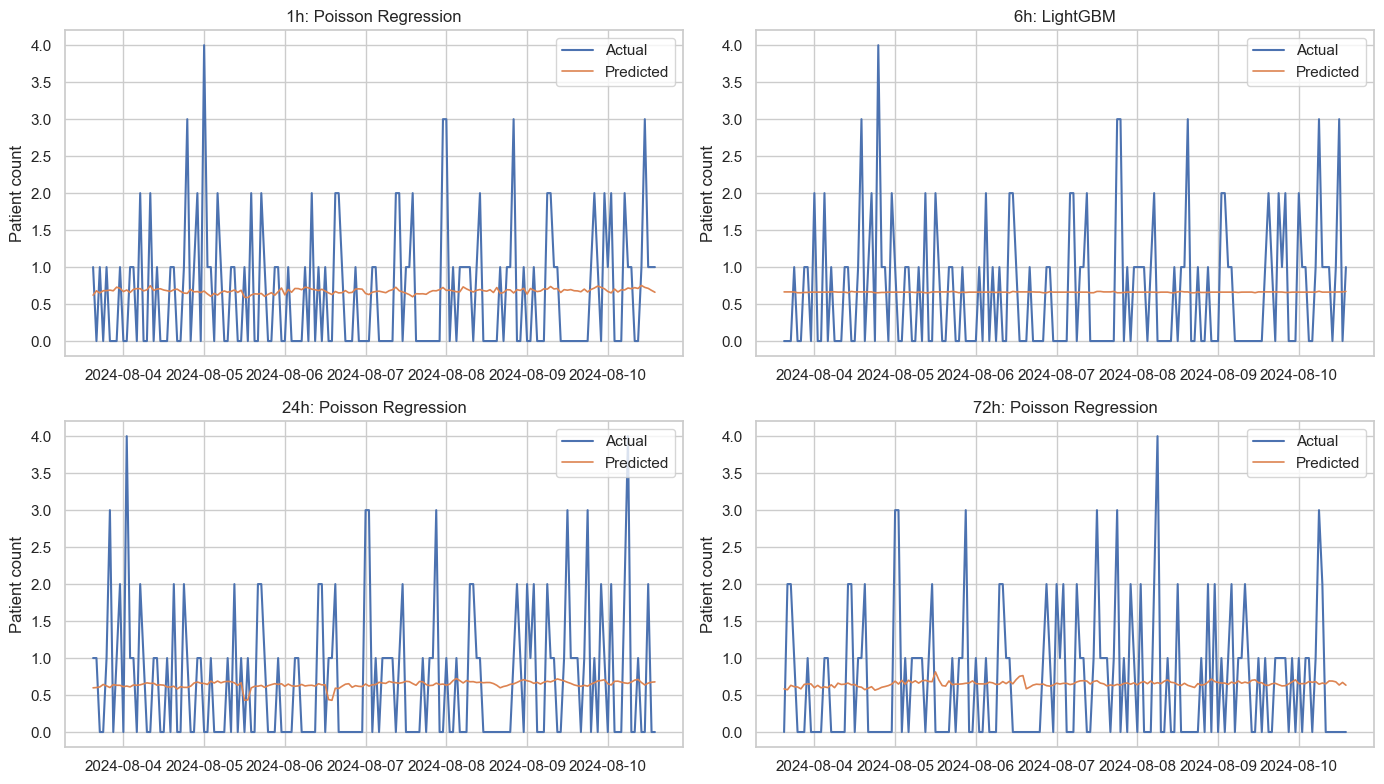

In [32]:
# Combine metrics and visualize the best available model for each horizon.
model_metrics = pd.concat(metric_frames, ignore_index=True)
model_metrics["Rank_By_RMSE"] = model_metrics.groupby("Horizon")["RMSE"].rank(method="dense")
model_metrics = model_metrics.sort_values(["Horizon", "RMSE"]).reset_index(drop=True)
best_model_by_horizon = model_metrics.loc[model_metrics.groupby("Horizon")["RMSE"].idxmin()].reset_index(drop=True)

display(model_metrics)
print("\nBest model by horizon:")
display(best_model_by_horizon)

expected_horizon_labels = {f"{horizon}h" for horizon in forecast_horizons}
if set(best_model_by_horizon["Horizon"]) != expected_horizon_labels:
    raise ValueError("Best-model table does not contain exactly one winner per horizon.")

plot_rows = min(168, len(y_test))
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False)
axes = axes.ravel()

for axis, (horizon, target_column) in zip(axes, forecast_horizons.items()):
    horizon_label = f"{horizon}h"
    best_model_name = best_model_by_horizon.loc[best_model_by_horizon["Horizon"] == horizon_label, "Model"].iloc[0]
    predictions = prediction_store[best_model_name].loc[y_test.index, target_column]
    plot_dates = date_test.iloc[:plot_rows]
    axis.plot(plot_dates, y_test[target_column].iloc[:plot_rows], label="Actual", linewidth=1.5)
    axis.plot(plot_dates, predictions.iloc[:plot_rows], label="Predicted", linewidth=1.2)
    axis.set_title(f"{horizon_label}: {best_model_name}")
    axis.set_ylabel("Patient count")
    axis.legend(loc="upper right")

plt.tight_layout()
plt.show()

if model_notes:
    print("\nModel notes:")
    for note in model_notes:
        print(f"- {note}")


### Operations-Oriented Validation

Model validation should reflect how the forecast would be used as an operations tool. Overall accuracy matters, but staffing decisions also need to know whether the model misses during busy periods, underpredicts demand, or performs worse at specific hours or days.

| Metric | Why it matters |
|---|---|
| MAPE | General percentage accuracy where actual arrivals are nonzero |
| RMSE | Penalizes large misses that can disrupt staffing plans |
| Peak-period error | Captures performance when crowding risk is highest |
| Underprediction rate | Measures dangerous low forecasts that can lead to understaffing |
| Error by hour/day | Shows when staffing risk is highest |


,Horizon,Best_Model,Peak_Threshold,Peak_Rows,Peak_RMSE,Peak_MAE,Peak_Underprediction_Rate,Worst_Hour_By_MAE,Worst_Day_By_MAE
0,1h,Poisson Regression,1.0,991,0.963,0.721,1.0,5,Friday
1,6h,LightGBM,1.0,991,0.965,0.724,1.0,0,Sunday
2,24h,Poisson Regression,1.0,994,0.971,0.732,1.0,1,Thursday
3,72h,Poisson Regression,1.0,987,0.964,0.724,1.0,6,Tuesday


,Horizon,Best_Model,Hour,Rows,MAE,RMSE,Mean_Bias,Underprediction_Rate
0,1h,Poisson Regression,0,85,0.792,0.938,0.108,0.471
1,1h,Poisson Regression,1,85,0.661,0.772,0.041,0.529
2,1h,Poisson Regression,2,85,0.663,0.770,-0.030,0.471
3,1h,Poisson Regression,3,85,0.667,0.752,-0.075,0.435
4,1h,Poisson Regression,4,85,0.714,0.849,-0.019,0.447
...,...,...,...,...,...,...,...,...
91,72h,Poisson Regression,19,86,0.703,0.830,0.050,0.488
92,72h,Poisson Regression,20,86,0.625,0.764,-0.010,0.512
93,72h,Poisson Regression,21,86,0.686,0.842,0.018,0.488
94,72h,Poisson Regression,22,86,0.666,0.751,-0.061,0.453


,Horizon,Best_Model,Day_Of_Week,Rows,MAE,RMSE,Mean_Bias,Underprediction_Rate
0,1h,Poisson Regression,Friday,288,0.720,0.849,-0.003,0.458
1,1h,Poisson Regression,Monday,288,0.661,0.786,0.009,0.497
2,1h,Poisson Regression,Saturday,297,0.680,0.834,0.063,0.542
3,1h,Poisson Regression,Sunday,312,0.712,0.849,0.021,0.478
4,1h,Poisson Regression,Thursday,288,0.691,0.810,-0.061,0.451
5,1h,Poisson Regression,Tuesday,288,0.708,0.859,0.052,0.493
6,1h,Poisson Regression,Wednesday,288,0.655,0.755,-0.029,0.465
14,24h,Poisson Regression,Friday,288,0.696,0.851,0.080,0.538
15,24h,Poisson Regression,Monday,288,0.703,0.855,0.075,0.503
16,24h,Poisson Regression,Saturday,297,0.696,0.831,0.024,0.488


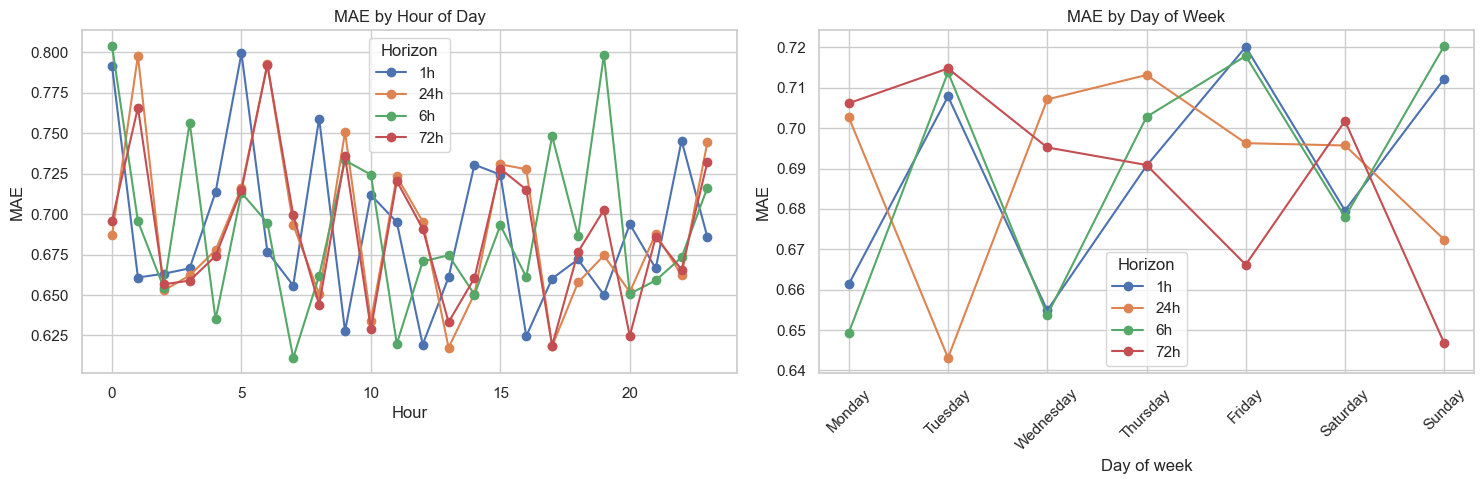

In [33]:
# Evaluate the best model per horizon like an operations staffing tool.
def grouped_error_summary(error_df, group_column):
    rows = []
    for group_value, group_df in error_df.groupby(group_column):
        rows.append(
            {
                group_column: group_value,
                "Rows": len(group_df),
                "MAE": mean_absolute_error(group_df["Actual"], group_df["Predicted"]),
                "RMSE": np.sqrt(mean_squared_error(group_df["Actual"], group_df["Predicted"])),
                "Mean_Bias": group_df["Residual"].mean(),
                "Underprediction_Rate": (group_df["Residual"] > 0).mean(),
            }
        )
    return pd.DataFrame(rows)


operations_rows = []
hourly_error_frames = []
dayofweek_error_frames = []
valid_day_names = set(pd.date_range("2024-01-01", periods=7, freq="D").day_name())

for horizon, target_column in forecast_horizons.items():
    horizon_label = f"{horizon}h"
    best_model_name = best_model_by_horizon.loc[
        best_model_by_horizon["Horizon"] == horizon_label,
        "Model",
    ].iloc[0]
    predictions = prediction_store[best_model_name].loc[y_test.index, target_column]
    actual = y_test[target_column]

    error_df = pd.DataFrame(
        {
            "DateTime_Hour": date_test.values,
            "Actual": actual.values,
            "Predicted": predictions.values,
        },
        index=y_test.index,
    )
    error_df["Predicted"] = error_df["Predicted"].clip(lower=0)
    error_df["Residual"] = error_df["Actual"] - error_df["Predicted"]
    error_df["Absolute_Error"] = error_df["Residual"].abs()
    error_df["Hour"] = pd.to_datetime(error_df["DateTime_Hour"]).dt.hour
    error_df["Day_Of_Week"] = pd.to_datetime(error_df["DateTime_Hour"]).dt.day_name()

    peak_threshold = error_df["Actual"].quantile(0.75)
    peak_df = error_df[error_df["Actual"] >= peak_threshold]
    if peak_df.empty:
        raise ValueError(f"Peak-period subset is empty for {horizon_label}.")

    hourly_summary = grouped_error_summary(error_df, "Hour")
    hourly_summary["Horizon"] = horizon_label
    hourly_summary["Best_Model"] = best_model_name
    hourly_error_frames.append(hourly_summary)

    day_summary = grouped_error_summary(error_df, "Day_Of_Week")
    day_summary["Horizon"] = horizon_label
    day_summary["Best_Model"] = best_model_name
    dayofweek_error_frames.append(day_summary)

    worst_hour = hourly_summary.sort_values("MAE", ascending=False).iloc[0]["Hour"]
    worst_day = day_summary.sort_values("MAE", ascending=False).iloc[0]["Day_Of_Week"]

    operations_rows.append(
        {
            "Horizon": horizon_label,
            "Best_Model": best_model_name,
            "Peak_Threshold": peak_threshold,
            "Peak_Rows": len(peak_df),
            "Peak_RMSE": np.sqrt(mean_squared_error(peak_df["Actual"], peak_df["Predicted"])),
            "Peak_MAE": mean_absolute_error(peak_df["Actual"], peak_df["Predicted"]),
            "Peak_Underprediction_Rate": (peak_df["Residual"] > 0).mean(),
            "Worst_Hour_By_MAE": worst_hour,
            "Worst_Day_By_MAE": worst_day,
        }
    )

operations_validation_summary = pd.DataFrame(operations_rows)
hourly_error_summary = pd.concat(hourly_error_frames, ignore_index=True)[
    ["Horizon", "Best_Model", "Hour", "Rows", "MAE", "RMSE", "Mean_Bias", "Underprediction_Rate"]
]
dayofweek_error_summary = pd.concat(dayofweek_error_frames, ignore_index=True)[
    ["Horizon", "Best_Model", "Day_Of_Week", "Rows", "MAE", "RMSE", "Mean_Bias", "Underprediction_Rate"]
]

display(operations_validation_summary.round(3))
display(hourly_error_summary.sort_values(["Horizon", "Hour"]).round(3))
display(dayofweek_error_summary.sort_values(["Horizon", "Day_Of_Week"]).round(3))

# Plot operational error by hour and day of week.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for horizon_label, horizon_df in hourly_error_summary.groupby("Horizon"):
    axes[0].plot(horizon_df.sort_values("Hour")["Hour"], horizon_df.sort_values("Hour")["MAE"], marker="o", label=horizon_label)
axes[0].set_title("MAE by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("MAE")
axes[0].legend(title="Horizon")

ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
for horizon_label, horizon_df in dayofweek_error_summary.groupby("Horizon"):
    day_plot_df = horizon_df.set_index("Day_Of_Week").reindex(ordered_days).reset_index()
    axes[1].plot(day_plot_df["Day_Of_Week"], day_plot_df["MAE"], marker="o", label=horizon_label)
axes[1].set_title("MAE by Day of Week")
axes[1].set_xlabel("Day of week")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Horizon")

plt.tight_layout()
plt.show()

expected_horizon_labels = {f"{horizon}h" for horizon in forecast_horizons}
if set(operations_validation_summary["Horizon"]) != expected_horizon_labels:
    raise ValueError("Operations validation summary does not contain all horizons.")
if (operations_validation_summary["Peak_Rows"] <= 0).any():
    raise ValueError("Each horizon must have non-empty peak-period rows.")
if not set(hourly_error_summary["Hour"]).issubset(set(range(24))):
    raise ValueError("Hourly error summary contains invalid hour values.")
if not set(dayofweek_error_summary["Day_Of_Week"]).issubset(valid_day_names):
    raise ValueError("Day-of-week error summary contains invalid day names.")
metric_columns = ["Peak_Threshold", "Peak_RMSE", "Peak_MAE", "Peak_Underprediction_Rate"]
if not np.isfinite(operations_validation_summary[metric_columns].to_numpy(dtype=float)).all():
    raise ValueError("Operations validation summary contains non-finite metrics.")


> **Interpretation:** These operational metrics show whether the selected models are safe to use for staffing support. Peak-period error focuses on crowded hours, underprediction rate highlights understaffing risk, and hour/day summaries reveal when forecast misses are most likely to create operational pressure.


## Final Summary

The model comparison identifies the strongest model separately for each forecast horizon because 1-hour, 6-hour, 24-hour, and 72-hour forecasts answer different operational questions. The final summary below combines the best-model table with the operations validation metrics so model choice can be judged by both statistical accuracy and staffing risk.

The main project conclusion is that leakage-safe lag, rolling, calendar, flu-season, and weather features create a useful short-term ER forecasting table. More complex models are helpful when they improve a specific horizon, but simpler count-aware regression can remain competitive for low hourly arrival counts with many zero-arrival periods.


In [34]:
# Summarize the final selected model, core error metrics, and operational risk by horizon.
final_model_summary = (
    best_model_by_horizon[
        ["Horizon", "Model", "RMSE", "MAE", "MAPE", "Mean_Bias", "Underprediction_Rate"]
    ]
    .merge(
        operations_validation_summary[
            ["Horizon", "Peak_RMSE", "Peak_MAE", "Peak_Underprediction_Rate", "Worst_Hour_By_MAE", "Worst_Day_By_MAE"]
        ],
        on="Horizon",
        how="left",
    )
    .rename(columns={"Model": "Best_Model"})
    .sort_values("Horizon")
)

display(final_model_summary.round(3))


,Horizon,Best_Model,RMSE,MAE,MAPE,Mean_Bias,Underprediction_Rate,Peak_RMSE,Peak_MAE,Peak_Underprediction_Rate,Worst_Hour_By_MAE,Worst_Day_By_MAE
0,1h,Poisson Regression,0.821,0.690,44.877,0.008,0.484,0.963,0.721,1.0,5,Friday
1,24h,Poisson Regression,0.822,0.690,45.840,0.020,0.485,0.971,0.732,1.0,1,Thursday
2,6h,LightGBM,0.822,0.691,44.987,0.009,0.484,0.965,0.724,1.0,0,Sunday
3,72h,Poisson Regression,0.819,0.688,45.188,0.009,0.482,0.964,0.724,1.0,6,Tuesday


### Limitations and Future Work

This notebook is complete as a short-term ER patient-volume forecasting project. It does not claim to complete medium- or long-term seasonal forecasting, LSTM modeling, or a formal staffing/wait-time simulation. Those are appropriate future extensions once the short-term workflow is validated with additional operational data and stakeholder-defined staffing rules.
